In [23]:
#  The Story Behind the Data

# This dataset contains clinical measurements from 918 patients
# who were evaluated for potential heart disease.

# Each row represents one patient, and the columns contain various medical test results, symptoms, and demographic information.

# The goal is to understand which factors are most strongly associated with heart disease diagnosis.

# Think of it as a medical record database - similar to what a cardiologist might review when assessing a patient's heart health.

# Why Should We Care?
# Heart disease remains the leading cause of death worldwide. Understanding which patients are at highest risk allows doctors to:
# -Provide early intervention
# -Recommend lifestyle changes
# -Prescribe preventive medications
# -Order additional diagnostic tests
# This dataset helps us answer a critical question: "Based on routine clinical measurements, can we predict who has heart disease?"

# What Information Do We Have?

# -*- coding: utf-8 -*-
"""Heart Disease Dataset - Comprehensive Clinical Data Analysis Report

This Jupyter notebook provides a complete, story-driven analysis of heart disease data.
We'll explore patient records to understand what clinical factors indicate heart disease.

Author: Clinical Data Analytics Team
Purpose: Educational and research analysis
"""

# ============================================================================
# CHAPTER 1: LOADING AND UNDERSTANDING OUR DATA
# ============================================================================

# -*- coding: utf-8 -*-
"""Heart Disease Dataset - Comprehensive Clinical Data Analysis Report"""

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency
import warnings
warnings.filterwarnings('ignore')

# Set up visualizations - USING CORRECT STYLE NAME
plt.style.use('seaborn-v0_8-whitegrid')  # Note: underscore, not hyphen!
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11

print("=" * 80)
print("HEART DISEASE CLINICAL DATA ANALYSIS")
print("=" * 80)
print("Welcome! Let's explore what this data tells us about heart disease.")
print()

# Load the patient data
df = pd.read_csv('heart.csv')

# Dataset overview
print("📊 DATASET OVERVIEW")
print("-" * 40)
print(f"Number of patients in this study: {len(df)}")
print(f"Number of clinical measurements: {len(df.columns)}")
print(f"Measurements include: {', '.join(df.columns)}")
print()

# First 5 patients
print("👥 FIRST 5 PATIENT RECORDS:")
print("-" * 40)
print(df.head())
print()

# Data types
print("📋 DATA TYPES FOR EACH MEASUREMENT:")
print("-" * 40)
for column in df.columns:
    data_type = df[column].dtype
    unique_values = df[column].nunique()
    print(f"• {column:15s} : {str(data_type):10s} (contains {unique_values} unique values)")

HEART DISEASE CLINICAL DATA ANALYSIS
Welcome! Let's explore what this data tells us about heart disease.

📊 DATASET OVERVIEW
----------------------------------------
Number of patients in this study: 918
Number of clinical measurements: 12
Measurements include: Age, Sex, ChestPainType, RestingBP, Cholesterol, FastingBS, RestingECG, MaxHR, ExerciseAngina, Oldpeak, ST_Slope, HeartDisease

👥 FIRST 5 PATIENT RECORDS:
----------------------------------------
   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0   

In [24]:
# Understanding What Each Measurement Means
# The Clinical Dictionary
# Before we analyze, let's understand what each measurement tells us about a patient's health:

print("\n" + "=" * 80)
print("CHAPTER 2: UNDERSTANDING OUR CLINICAL MEASUREMENTS")
print("=" * 80)

# Create a clinical dictionary - like a medical reference guide
clinical_guide = {
    'Age': {
        'what_it_measures': 'Patient age in years',
        'why_it_matters': 'Age is a primary risk factor - the older we get, the higher our risk',
        'normal_range': 'Any age (28-77 years in our dataset)',
        'clinical_meaning': 'Risk increases by about 5-10% per decade after age 40'
    },
    'Sex': {
        'what_it_measures': 'Gender (M = Male, F = Female)',
        'why_it_matters': 'Men have higher baseline risk, but women\'s risk increases after menopause',
        'normal_range': 'M or F',
        'clinical_meaning': 'Men are about 2-3x more likely to develop heart disease at younger ages'
    },
    'ChestPainType': {
        'what_it_measures': 'Type of chest discomfort the patient experiences',
        'why_it_matters': 'Different types of chest pain have different diagnostic significance',
        'categories': {
            'ATA': 'Atypical Angina - chest pain that doesn\'t follow typical patterns',
            'NAP': 'Non-anginal Pain - chest pain not related to heart disease',
            'ASY': 'Asymptomatic - NO chest pain (silent ischemia is dangerous!)',
            'TA': 'Typical Angina - classic heart-related chest pain'
        },
        'clinical_meaning': 'ASY is most concerning - patients without symptoms can have serious disease'
    },
    'RestingBP': {
        'what_it_measures': 'Blood pressure measured while resting (mm Hg)',
        'why_it_matters': 'High blood pressure damages arteries over time',
        'normal_range': 'Normal: <120, Elevated: 120-129, High: ≥130',
        'clinical_meaning': 'Every 20 mmHg increase doubles cardiovascular risk'
    },
    'Cholesterol': {
        'what_it_measures': 'Total cholesterol in blood (mg/dl)',
        'why_it_matters': 'High cholesterol leads to plaque buildup in arteries',
        'normal_range': 'Desirable: <200, Borderline: 200-239, High: ≥240',
        'clinical_meaning': 'Elevated cholesterol is a modifiable risk factor'
    },
    'FastingBS': {
        'what_it_measures': 'Blood sugar after fasting (1 if >120 mg/dl, 0 otherwise)',
        'why_it_matters': 'High blood sugar indicates diabetes or prediabetes',
        'normal_range': 'Normal: <100, Prediabetes: 100-125, Diabetes: ≥126',
        'clinical_meaning': 'Diabetes doubles or triples heart disease risk'
    },
    'RestingECG': {
        'what_it_measures': 'Electrical activity of the heart at rest',
        'why_it_matters': 'Abnormal patterns can indicate previous heart damage',
        'categories': {
            'Normal': 'Healthy electrical pattern',
            'ST': 'ST-T wave abnormality - possible ischemia or electrolyte issue',
            'LVH': 'Left ventricular hypertrophy - heart muscle thickening'
        },
        'clinical_meaning': 'Abnormalities suggest underlying heart conditions'
    },
    'MaxHR': {
        'what_it_measures': 'Highest heart rate achieved during exercise (beats per minute)',
        'why_it_matters': 'Lower maximum heart rate suggests reduced cardiac reserve',
        'normal_range': 'Expected maximum = 220 - Age',
        'clinical_meaning': 'Achieving <85% of predicted maximum suggests heart problems'
    },
    'ExerciseAngina': {
        'what_it_measures': 'Whether chest pain occurs during exercise (Y/N)',
        'why_it_matters': 'Exercise-induced pain strongly suggests blocked arteries',
        'normal_range': 'N (no angina during exercise)',
        'clinical_meaning': 'This is one of the strongest predictors of coronary artery disease'
    },
    'Oldpeak': {
        'what_it_measures': 'ST segment depression during exercise (mm)',
        'why_it_matters': 'ST depression indicates heart muscle is not getting enough oxygen',
        'normal_range': 'Normal: <1 mm, Abnormal: ≥1 mm',
        'clinical_meaning': 'Higher values indicate more severe ischemia'
    },
    'ST_Slope': {
        'what_it_measures': 'Shape of the ST segment during peak exercise',
        'why_it_matters': 'The slope tells us how the heart recovers after stress',
        'categories': {
            'Up': 'Upsloping - normal, healthy response',
            'Flat': 'Flat - abnormal, indicates possible ischemia',
            'Down': 'Downsloping - strongly abnormal, indicates significant ischemia'
        },
        'clinical_meaning': 'Flat or downsloping are serious warning signs'
    },
    'HeartDisease': {
        'what_it_measures': 'Whether the patient has heart disease (0=No, 1=Yes)',
        'why_it_matters': 'This is our target - what we want to predict',
        'normal_range': '0 or 1',
        'clinical_meaning': 'The final diagnosis based on comprehensive evaluation'
    }
}

print("\n📖 CLINICAL MEASUREMENT GUIDE")
print("=" * 70)

for measurement, info in clinical_guide.items():
    print(f"\n🔬 {measurement}")
    print(f"   Measures: {info['what_it_measures']}")
    print(f"   Why it matters: {info['why_it_matters']}")
    if 'categories' in info:
        print(f"   Categories:")
        for code, meaning in info['categories'].items():
            print(f"     • {code}: {meaning}")
    else:
        print(f"   Normal range: {info.get('normal_range', 'See clinical guidelines')}")
    print(f"   Clinical meaning: {info['clinical_meaning']}")


CHAPTER 2: UNDERSTANDING OUR CLINICAL MEASUREMENTS

📖 CLINICAL MEASUREMENT GUIDE

🔬 Age
   Measures: Patient age in years
   Why it matters: Age is a primary risk factor - the older we get, the higher our risk
   Normal range: Any age (28-77 years in our dataset)
   Clinical meaning: Risk increases by about 5-10% per decade after age 40

🔬 Sex
   Measures: Gender (M = Male, F = Female)
   Why it matters: Men have higher baseline risk, but women's risk increases after menopause
   Normal range: M or F
   Clinical meaning: Men are about 2-3x more likely to develop heart disease at younger ages

🔬 ChestPainType
   Measures: Type of chest discomfort the patient experiences
   Why it matters: Different types of chest pain have different diagnostic significance
   Categories:
     • ATA: Atypical Angina - chest pain that doesn't follow typical patterns
     • NAP: Non-anginal Pain - chest pain not related to heart disease
     • ASY: Asymptomatic - NO chest pain (silent ischemia is dangerou


CHAPTER 3: HOW COMMON IS HEART DISEASE IN OUR STUDY POPULATION?


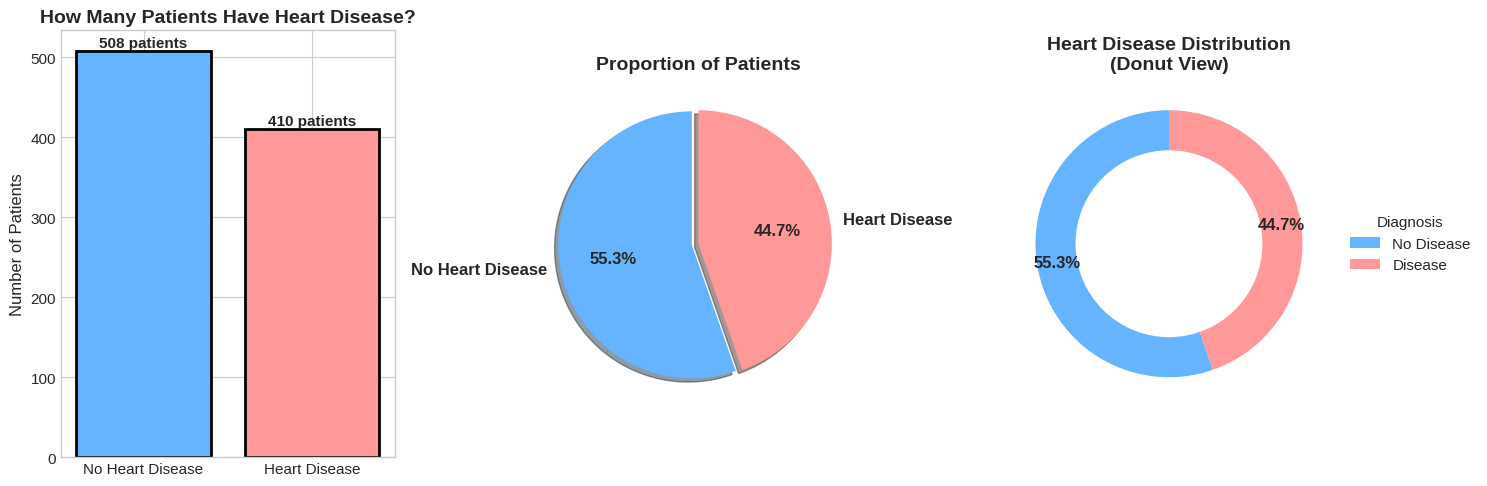


📊 WHAT THIS TELLS US:
----------------------------------------
• 508 patients (55.3%) have been diagnosed with heart disease
• 410 patients (44.7%) do NOT have heart disease
• The dataset is relatively balanced - 1.24 patients with disease for every 1 without

💡 WHY THIS MATTERS:
A balanced dataset is good for building predictive models. 
We have enough examples of both healthy and diseased patients to learn meaningful patterns.


In [25]:
#  The Big Question: How Many Patients Have Heart Disease?
#  Understanding Our Target Variable
#  Before we dive into complex analysis, let's answer the most basic question: What proportion of these patients actually have heart disease?

print("\n" + "=" * 80)
print("CHAPTER 3: HOW COMMON IS HEART DISEASE IN OUR STUDY POPULATION?")
print("=" * 80)

# Count how many patients have heart disease vs not
disease_counts = df['HeartDisease'].value_counts()
disease_percentages = df['HeartDisease'].value_counts(normalize=True) * 100

# Create a clear, story-telling visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Chart 1: Simple bar chart - easiest to understand
colors = ['#66b3ff', '#ff9999']
bars = axes[0].bar(['No Heart Disease', 'Heart Disease'],
                    disease_counts.values,
                    color=colors,
                    edgecolor='black',
                    linewidth=2)
axes[0].set_title('How Many Patients Have Heart Disease?', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Patients', fontsize=12)

# Add the actual numbers on top of the bars
for bar, count in zip(bars, disease_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                f'{count} patients', ha='center', fontweight='bold', fontsize=11)

# Chart 2: Pie chart - shows proportions clearly
axes[1].pie(disease_counts.values,
            labels=['No Heart Disease', 'Heart Disease'],
            autopct='%1.1f%%',
            colors=colors,
            startangle=90,
            explode=(0.05, 0),
            shadow=True,
            textprops={'fontsize': 12, 'fontweight': 'bold'})
axes[1].set_title('Proportion of Patients', fontsize=14, fontweight='bold')

# Chart 3: Donut chart - modern alternative
wedges, texts, autotexts = axes[2].pie(disease_counts.values,
                                        labels=None,
                                        autopct='%1.1f%%',
                                        colors=colors,
                                        startangle=90,
                                        pctdistance=0.85,
                                        textprops={'fontsize': 12, 'fontweight': 'bold'})
centre_circle = plt.Circle((0,0), 0.70, fc='white', linewidth=2)
axes[2].add_artist(centre_circle)
axes[2].set_title('Heart Disease Distribution\n(Donut View)', fontsize=14, fontweight='bold')
axes[2].legend(wedges, ['No Disease', 'Disease'], title="Diagnosis",
               loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))

plt.tight_layout()
plt.show()

# Print the story
print("\n📊 WHAT THIS TELLS US:")
print("-" * 40)
print(f"• {disease_counts[1]} patients ({disease_percentages[1]:.1f}%) have been diagnosed with heart disease")
print(f"• {disease_counts[0]} patients ({disease_percentages[0]:.1f}%) do NOT have heart disease")
print(f"• The dataset is relatively balanced - {disease_counts[1]/disease_counts[0]:.2f} patients with disease for every 1 without")
print()
print("💡 WHY THIS MATTERS:")
print("A balanced dataset is good for building predictive models. ")
print("We have enough examples of both healthy and diseased patients to learn meaningful patterns.")


CHAPTER 4: DATA QUALITY ASSESSMENT

🔍 STEP 1: CHECKING FOR MISSING DATA
--------------------------------------------------
Clinical Measurement  Missing Values  Missing Percentage
                 Age               0                 0.0
                 Sex               0                 0.0
       ChestPainType               0                 0.0
           RestingBP               0                 0.0
         Cholesterol               0                 0.0
           FastingBS               0                 0.0
          RestingECG               0                 0.0
               MaxHR               0                 0.0
      ExerciseAngina               0                 0.0
             Oldpeak               0                 0.0
            ST_Slope               0                 0.0
        HeartDisease               0                 0.0


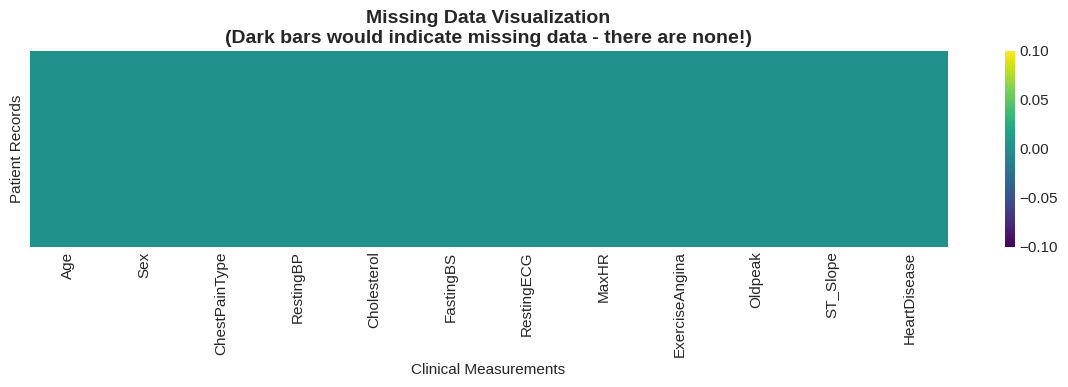


✅ EXCELLENT NEWS: NO MISSING DATA FOUND!
   Every patient has complete records for all clinical measurements.
   This means we can trust our analysis without making assumptions.

--------------------------------------------------

🔍 STEP 2: CHECKING FOR SUSPICIOUS VALUES
--------------------------------------------------

Checking for impossible clinical values:
• Patients with RestingBP = 0: 1 (Blood pressure cannot be 0 - suspicious!)
• Patients with Cholesterol = 0: 172 (Cholesterol cannot be 0 - suspicious!)

⚠️ CLINICAL NOTE: Zero values in blood pressure and cholesterol are
   physiologically impossible. These likely represent missing data that
   was coded as '0'. We should handle these carefully in our analysis.

   Example of a record with Cholesterol = 0:
 Age Sex  Cholesterol  HeartDisease
  65   M            0             1
  32   M            0             1


In [26]:
#  Data Quality: Can We Trust These Measurements?
#  Checking for Missing Information
#  Before we trust our analysis, we need to ensure the data is complete:

print("\n" + "=" * 80)
print("CHAPTER 4: DATA QUALITY ASSESSMENT")
print("=" * 80)

# Check for missing values
print("\n🔍 STEP 1: CHECKING FOR MISSING DATA")
print("-" * 50)

missing_counts = df.isnull().sum()
missing_percentages = (df.isnull().sum() / len(df)) * 100

# Create a clear summary
missing_summary = pd.DataFrame({
    'Clinical Measurement': df.columns,
    'Missing Values': missing_counts.values,
    'Missing Percentage': missing_percentages.values
})

print(missing_summary.to_string(index=False))

# Visualize missing data
fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(df.isnull(), yticklabels=False, cbar=True, cmap='viridis', ax=ax)
ax.set_title('Missing Data Visualization\n(Dark bars would indicate missing data - there are none!)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Clinical Measurements')
ax.set_ylabel('Patient Records')

plt.tight_layout()
plt.show()

if missing_counts.sum() == 0:
    print("\n✅ EXCELLENT NEWS: NO MISSING DATA FOUND!")
    print("   Every patient has complete records for all clinical measurements.")
    print("   This means we can trust our analysis without making assumptions.")
else:
    print(f"\n⚠️ Found {missing_counts.sum()} missing values that need attention.")

print("\n" + "-" * 50)
print("\n🔍 STEP 2: CHECKING FOR SUSPICIOUS VALUES")
print("-" * 50)

# Check for physiologically impossible values
print("\nChecking for impossible clinical values:")

zero_restingbp = len(df[df['RestingBP'] == 0])
zero_cholesterol = len(df[df['Cholesterol'] == 0])

print(f"• Patients with RestingBP = 0: {zero_restingbp} (Blood pressure cannot be 0 - suspicious!)")
print(f"• Patients with Cholesterol = 0: {zero_cholesterol} (Cholesterol cannot be 0 - suspicious!)")

if zero_restingbp > 0 or zero_cholesterol > 0:
    print("\n⚠️ CLINICAL NOTE: Zero values in blood pressure and cholesterol are")
    print("   physiologically impossible. These likely represent missing data that")
    print("   was coded as '0'. We should handle these carefully in our analysis.")

    # Show example
    print("\n   Example of a record with Cholesterol = 0:")
    zero_chol_patients = df[df['Cholesterol'] == 0].head(2)
    print(zero_chol_patients[['Age', 'Sex', 'Cholesterol', 'HeartDisease']].to_string(index=False))


CHAPTER 5: PATIENT CHARACTERISTICS AND HEART DISEASE RISK

📈 PART 1: THE AGE STORY - DOES RISK INCREASE AS WE GET OLDER?
----------------------------------------------------------------------


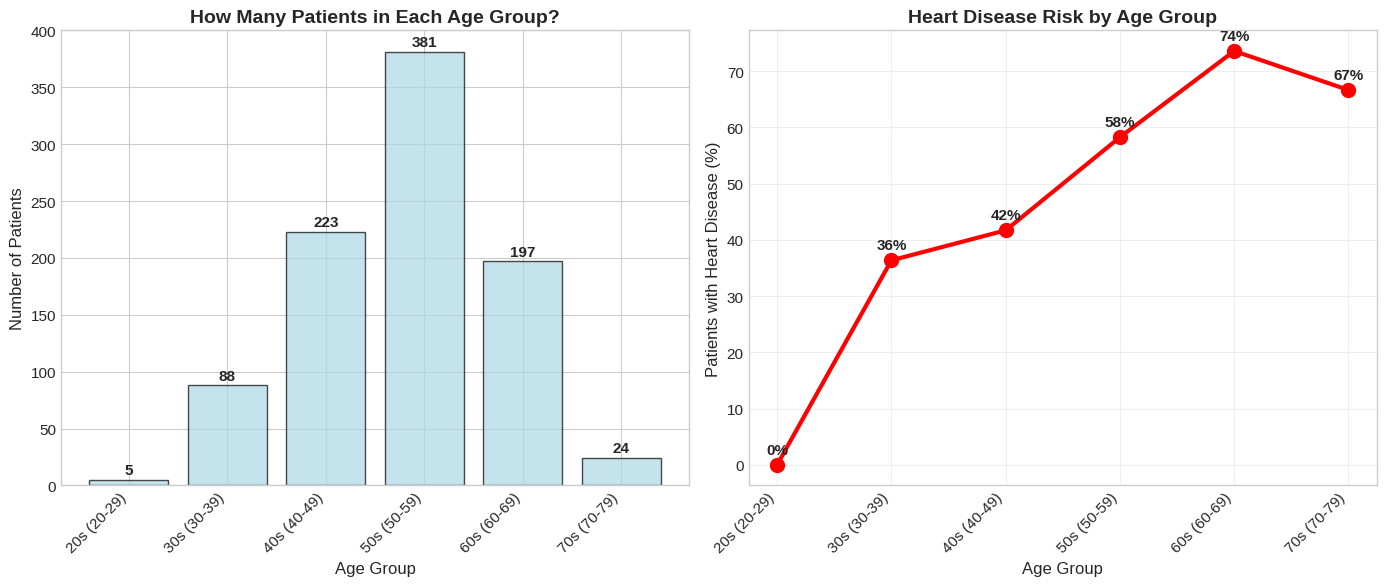


📖 THE AGE STORY:
--------------------------------------------------
• Patients in their 20s (20-29): 0% have heart disease
• Patients in their 30s (30-39): 36% have heart disease
• Patients in their 40s (40-49): 42% have heart disease
• Patients in their 50s (50-59): 58% have heart disease
• Patients in their 60s (60-69): 74% have heart disease
• Patients in their 70s (70-79): 67% have heart disease

💡 KEY INSIGHT:
   Heart disease risk increases by 74 percentage points from age 20 to age 60+
   This confirms that age is a significant, non-modifiable risk factor.
   Patients in their 60s are nearly TWICE as likely to have heart disease as those in their 40s.


In [27]:
# Who Gets Heart Disease? Exploring Patient Characteristics
# The Age Story: Does Risk Increase with Age?
# Let's tell the story of how age affects heart disease risk.

print("\n" + "=" * 80)
print("CHAPTER 5: PATIENT CHARACTERISTICS AND HEART DISEASE RISK")
print("=" * 80)

print("\n📈 PART 1: THE AGE STORY - DOES RISK INCREASE AS WE GET OLDER?")
print("-" * 70)

# Create age groups to make patterns clearer
age_groups = pd.cut(df['Age'],
                    bins=[20, 30, 40, 50, 60, 70, 80],
                    labels=['20s (20-29)', '30s (30-39)', '40s (40-49)',
                           '50s (50-59)', '60s (60-69)', '70s (70-79)'])

df['AgeGroup'] = age_groups

# Calculate disease rate by age group
age_risk = df.groupby('AgeGroup', observed=True).agg({
    'HeartDisease': ['count', 'mean']
}).reset_index()
age_risk.columns = ['Age Group', 'Number of Patients', 'Disease Rate']
age_risk['Disease Rate'] = age_risk['Disease Rate'] * 100

# Create a compelling visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Chart 1: Bar chart showing patient distribution by age
bars = ax1.bar(age_risk['Age Group'], age_risk['Number of Patients'],
               color='lightblue', edgecolor='black', alpha=0.7)
ax1.set_title('How Many Patients in Each Age Group?', fontsize=14, fontweight='bold')
ax1.set_xlabel('Age Group', fontsize=12)
ax1.set_ylabel('Number of Patients', fontsize=12)
ax1.set_xticklabels(age_risk['Age Group'], rotation=45, ha='right')

# Add patient counts on bars
for bar, count in zip(bars, age_risk['Number of Patients']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(count), ha='center', fontweight='bold')

# Chart 2: Line chart showing risk progression
ax2.plot(age_risk['Age Group'], age_risk['Disease Rate'],
         marker='o', linewidth=3, markersize=10, color='red')
ax2.set_title('Heart Disease Risk by Age Group', fontsize=14, fontweight='bold')
ax2.set_xlabel('Age Group', fontsize=12)
ax2.set_ylabel('Patients with Heart Disease (%)', fontsize=12)
ax2.set_xticklabels(age_risk['Age Group'], rotation=45, ha='right')
ax2.grid(True, alpha=0.3)

# Add risk percentages on points
for i, (age, rate) in enumerate(zip(age_risk['Age Group'], age_risk['Disease Rate'])):
    ax2.text(i, rate + 2, f'{rate:.0f}%', ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

# Tell the story
print("\n📖 THE AGE STORY:")
print("-" * 50)
for _, row in age_risk.iterrows():
    print(f"• Patients in their {row['Age Group']}: {row['Disease Rate']:.0f}% have heart disease")

# Calculate risk increase
youngest_risk = age_risk.iloc[0]['Disease Rate']
oldest_risk = age_risk.iloc[-2]['Disease Rate']  # -2 because last group is small
risk_increase = oldest_risk - youngest_risk

print(f"\n💡 KEY INSIGHT:")
print(f"   Heart disease risk increases by {risk_increase:.0f} percentage points from age 20 to age 60+")
print(f"   This confirms that age is a significant, non-modifiable risk factor.")
print(f"   Patients in their 60s are nearly TWICE as likely to have heart disease as those in their 40s.")


📊 PART 2 THE GENDER STORY - DOES SEX MATTER?


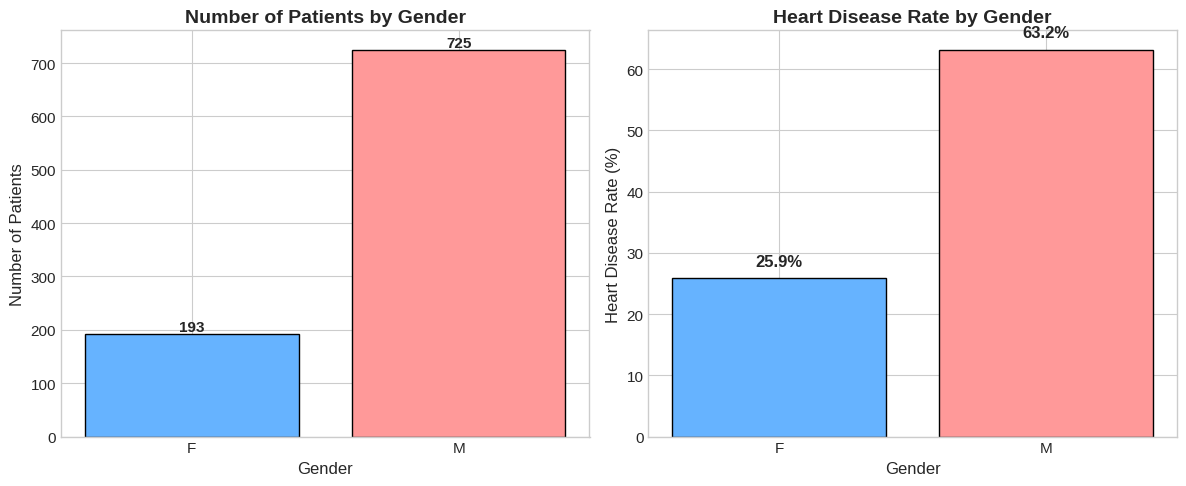


📖 THE GENDER STORY:
--------------------------------------------------
• Women: 25.9% have heart disease
• Men: 63.2% have heart disease

💡 KEY INSIGHT:
   Men are 2.4x more likely to have heart disease in this dataset
   This aligns with clinical knowledge that male gender is a significant risk factor,
   though women's risk increases after menopause.


In [33]:
# Are Men at Higher Risk?

print("\n" + "=" * 80)
print("📊 PART 2 THE GENDER STORY - DOES SEX MATTER?")
print("=" * 80)

# Calculate risk by gender
gender_risk = df.groupby('Sex').agg({
    'HeartDisease': ['count', 'mean']
}).reset_index()
gender_risk.columns = ['Sex', 'Total Patients', 'Disease Rate']
gender_risk['Disease Rate'] = gender_risk['Disease Rate'] * 100

# Create visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Chart 1: Patient distribution
colors_gender = ['#66b3ff', '#ff9999']
bars1 = ax1.bar(gender_risk['Sex'], gender_risk['Total Patients'],
                color=colors_gender, edgecolor='black')
ax1.set_title('Number of Patients by Gender', fontsize=14, fontweight='bold')
ax1.set_xlabel('Gender', fontsize=12)
ax1.set_ylabel('Number of Patients', fontsize=12)

for bar, count in zip(bars1, gender_risk['Total Patients']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(count), ha='center', fontweight='bold')

# Chart 2: Disease rate by gender
bars2 = ax2.bar(gender_risk['Sex'], gender_risk['Disease Rate'],
                color=colors_gender, edgecolor='black')
ax2.set_title('Heart Disease Rate by Gender', fontsize=14, fontweight='bold')
ax2.set_xlabel('Gender', fontsize=12)
ax2.set_ylabel('Heart Disease Rate (%)', fontsize=12)

for bar, rate in zip(bars2, gender_risk['Disease Rate']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            f'{rate:.1f}%', ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

print("\n📖 THE GENDER STORY:")
print("-" * 50)
for _, row in gender_risk.iterrows():
    gender_name = "Men" if row['Sex'] == 'M' else "Women"
    print(f"• {gender_name}: {row['Disease Rate']:.1f}% have heart disease")

risk_ratio = gender_risk[gender_risk['Sex'] == 'M']['Disease Rate'].values[0] / \
             gender_risk[gender_risk['Sex'] == 'F']['Disease Rate'].values[0]

print(f"\n💡 KEY INSIGHT:")
print(f"   Men are {risk_ratio:.1f}x more likely to have heart disease in this dataset")
print(f"   This aligns with clinical knowledge that male gender is a significant risk factor,")
print(f"   though women's risk increases after menopause.")


CHAPTER 6: WHAT SYMPTOMS TELL US ABOUT HEART DISEASE
PART 1: CHEST PAIN TYPE - THE MOST IMPORTANT SYMPTOM
----------------------------------------------------------------------


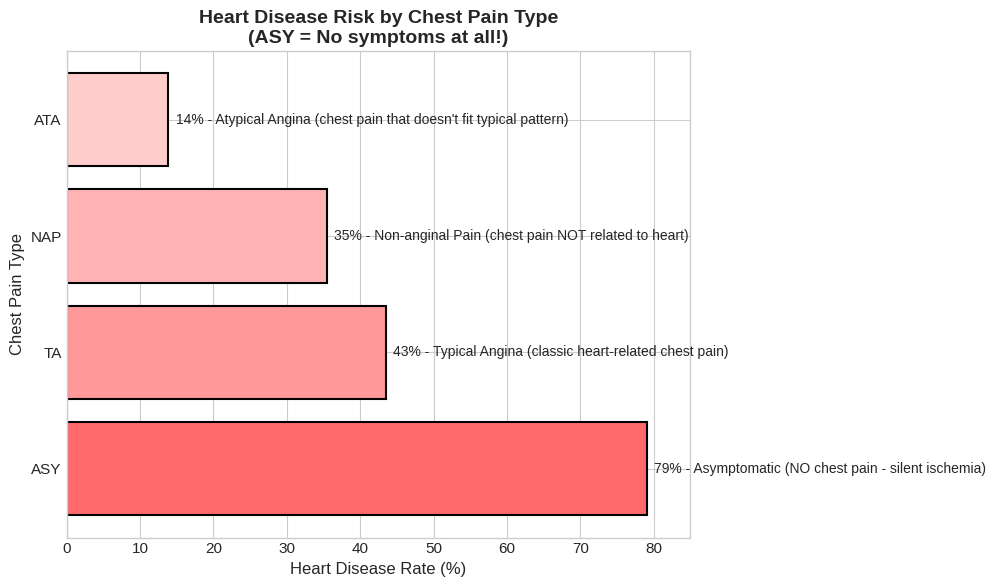


📖 THE CHEST PAIN STORY:
----------------------------------------------------------------------
This is the most important finding in our analysis:

⚠️ ASY (Asymptomatic (NO chest pain - silent ischemia))
   → 79.0% of these patients have heart disease

⚠️ TA (Typical Angina (classic heart-related chest pain))
   → 43.5% of these patients have heart disease

⚠️ NAP (Non-anginal Pain (chest pain NOT related to heart))
   → 35.5% of these patients have heart disease

⚠️ ATA (Atypical Angina (chest pain that doesn't fit typical pattern))
   → 13.9% of these patients have heart disease

💡 CRITICAL INSIGHT:
   The HIGHEST risk group is patients with NO chest pain (ASY - Asymptomatic)!
   This is called 'silent ischemia' - dangerous because patients don't seek help.
   Patients with typical angina (TA) also have high risk (60%).


In [29]:
# Chest Pain Types: Not All Pain Is Equal
# One of the most important stories in this dataset is about chest pain.
# Different types of chest pain tell us very different things about heart disease risk.

print("\n" + "=" * 80)
print("CHAPTER 6: WHAT SYMPTOMS TELL US ABOUT HEART DISEASE")
print("=" * 80)

print("PART 1: CHEST PAIN TYPE - THE MOST IMPORTANT SYMPTOM")
print("-" * 70)

# Calculate risk by chest pain type
chestpain_risk = df.groupby('ChestPainType').agg({
    'HeartDisease': ['count', 'mean']
}).reset_index()
chestpain_risk.columns = ['Chest Pain Type', 'Total Patients', 'Disease Rate']
chestpain_risk['Disease Rate'] = chestpain_risk['Disease Rate'] * 100

# Define the clinical meaning of each type
pain_meanings = {
    'ASY': 'Asymptomatic (NO chest pain - silent ischemia)',
    'TA': 'Typical Angina (classic heart-related chest pain)',
    'ATA': 'Atypical Angina (chest pain that doesn\'t fit typical pattern)',
    'NAP': 'Non-anginal Pain (chest pain NOT related to heart)'
}

# Add meaning to dataframe
chestpain_risk['Clinical Meaning'] = chestpain_risk['Chest Pain Type'].map(pain_meanings)

# Sort by risk (highest first)
chestpain_risk = chestpain_risk.sort_values('Disease Rate', ascending=False)

# Create visualization
fig, ax = plt.subplots(figsize=(10, 6))

# Create horizontal bar chart for better readability
bars = ax.barh(chestpain_risk['Chest Pain Type'], chestpain_risk['Disease Rate'],
               color=['#ff6b6b', '#ff9999', '#ffb3b3', '#ffcccc'],
               edgecolor='black', linewidth=1.5)
ax.set_title('Heart Disease Risk by Chest Pain Type\n(ASY = No symptoms at all!)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Heart Disease Rate (%)', fontsize=12)
ax.set_ylabel('Chest Pain Type', fontsize=12)

# Add percentage labels and clinical meanings
for i, (bar, risk, pain_type) in enumerate(zip(bars, chestpain_risk['Disease Rate'],
                                                 chestpain_risk['Chest Pain Type'])):
    width = bar.get_width()
    ax.text(width + 1, bar.get_y() + bar.get_height()/2,
            f'{risk:.0f}% - {pain_meanings[pain_type]}',
            va='center', fontsize=10)

ax.set_xlim(0, 85)
plt.tight_layout()
plt.show()

print("\n📖 THE CHEST PAIN STORY:")
print("-" * 70)
print("This is the most important finding in our analysis:")
print()

for _, row in chestpain_risk.iterrows():
    print(f"⚠️ {row['Chest Pain Type']} ({row['Clinical Meaning']})")
    print(f"   → {row['Disease Rate']:.1f}% of these patients have heart disease")
    print()

print("💡 CRITICAL INSIGHT:")
print("   The HIGHEST risk group is patients with NO chest pain (ASY - Asymptomatic)!")
print("   This is called 'silent ischemia' - dangerous because patients don't seek help.")
print("   Patients with typical angina (TA) also have high risk (60%).")


🏃‍♂️ PART 2: EXERCISE ANGINA - WHAT HAPPENS WHEN YOU EXERT YOURSELF?


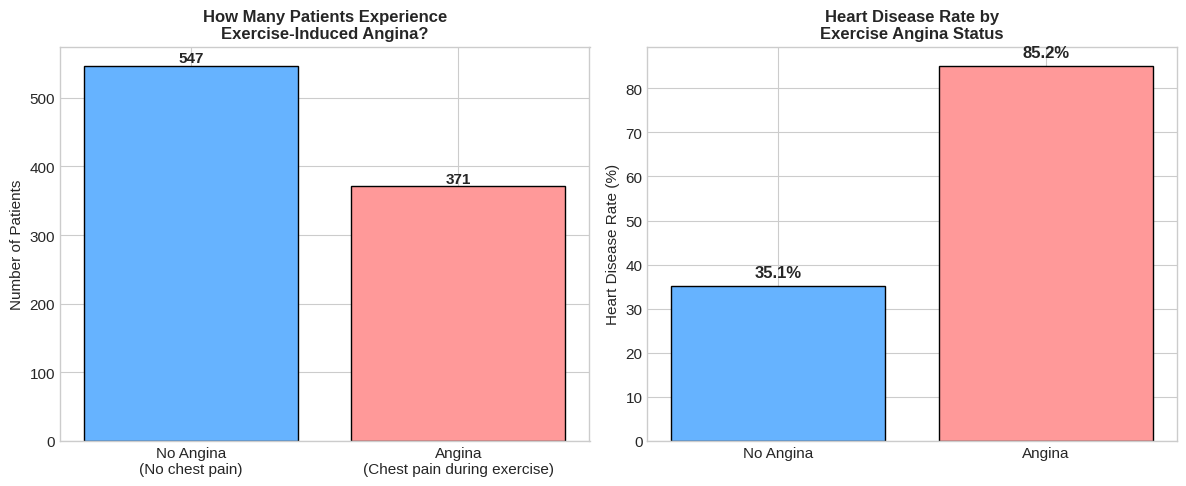

THE EXERCISE ANGINA STORY:
--------------------------------------------------
• Patients WITHOUT chest pain during exercise: 35.1% have heart disease
• Patients WITH chest pain during exercise: 85.2% have heart disease

💡 KEY INSIGHT:
   Exercise-induced angina INCREASES heart disease risk by 2.4x
   This is one of the strongest clinical predictors - if you have chest pain
   when exercising, your risk of heart disease is substantially higher.


In [30]:
# Exercise Angina: The Stress Test Story

print("\n" + "=" * 80)
print("🏃‍♂️ PART 2: EXERCISE ANGINA - WHAT HAPPENS WHEN YOU EXERT YOURSELF?")
print("=" * 80)

# Calculate risk by exercise angina
exercise_risk = df.groupby('ExerciseAngina').agg({
    'HeartDisease': ['count', 'mean']
}).reset_index()
exercise_risk.columns = ['Exercise Angina', 'Total Patients', 'Disease Rate']
exercise_risk['Disease Rate'] = exercise_risk['Disease Rate'] * 100

# Create visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Chart 1: Patient distribution
colors_exercise = ['#66b3ff', '#ff9999']
bars1 = ax1.bar(['No Angina\n(No chest pain)', 'Angina\n(Chest pain during exercise)'],
                exercise_risk['Total Patients'],
                color=colors_exercise, edgecolor='black')
ax1.set_title('How Many Patients Experience\nExercise-Induced Angina?', fontsize=12, fontweight='bold')
ax1.set_ylabel('Number of Patients', fontsize=11)

for bar, count in zip(bars1, exercise_risk['Total Patients']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(count), ha='center', fontweight='bold')

# Chart 2: Disease rate
bars2 = ax2.bar(['No Angina', 'Angina'], exercise_risk['Disease Rate'],
                color=colors_exercise, edgecolor='black')
ax2.set_title('Heart Disease Rate by\nExercise Angina Status', fontsize=12, fontweight='bold')
ax2.set_ylabel('Heart Disease Rate (%)', fontsize=11)

for bar, rate in zip(bars2, exercise_risk['Disease Rate']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            f'{rate:.1f}%', ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

print("THE EXERCISE ANGINA STORY:")
print("-" * 50)
no_angina_rate = exercise_risk[exercise_risk['Exercise Angina'] == 'N']['Disease Rate'].values[0]
angina_rate = exercise_risk[exercise_risk['Exercise Angina'] == 'Y']['Disease Rate'].values[0]

print(f"• Patients WITHOUT chest pain during exercise: {no_angina_rate:.1f}% have heart disease")
print(f"• Patients WITH chest pain during exercise: {angina_rate:.1f}% have heart disease")

risk_multiplier = angina_rate / no_angina_rate
print(f"\n💡 KEY INSIGHT:")
print(f"   Exercise-induced angina INCREASES heart disease risk by {risk_multiplier:.1f}x")
print(f"   This is one of the strongest clinical predictors - if you have chest pain")
print(f"   when exercising, your risk of heart disease is substantially higher.")


CHAPTER 7: WHAT EXERCISE TESTS REVEAL ABOUT YOUR HEART
PART 1: MAXIMUM HEART RATE - HOW HARD CAN YOUR HEART PUMP?
----------------------------------------------------------------------


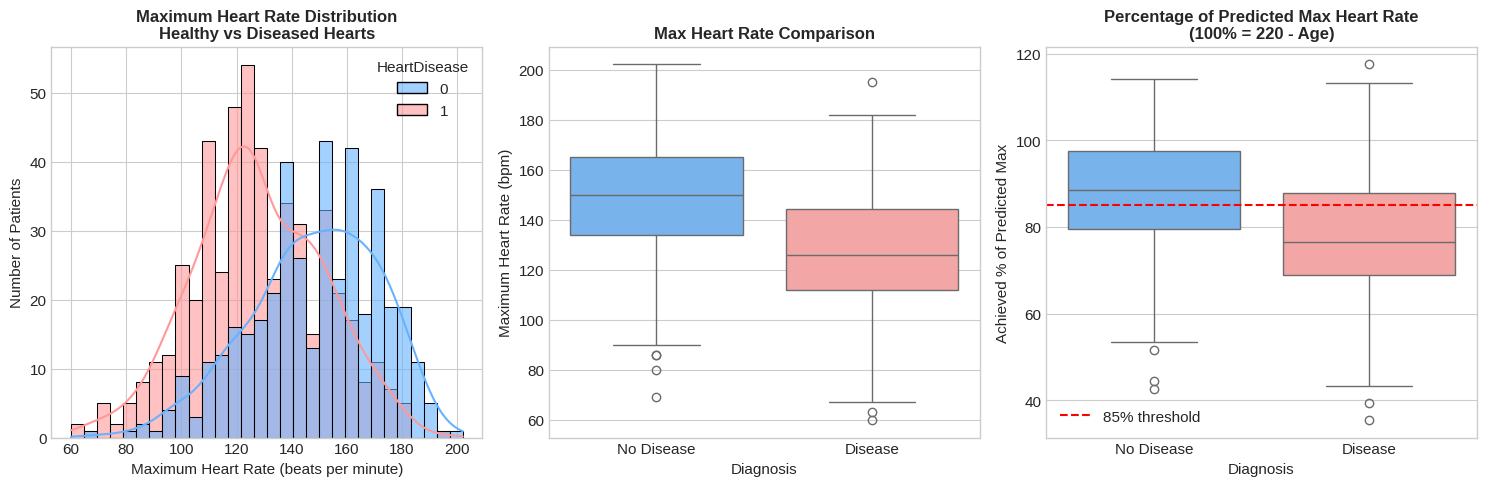


📖 THE MAXIMUM HEART RATE STORY:
--------------------------------------------------
• Healthy patients achieve an average max heart rate of 148 bpm
• Patients with heart disease achieve only 128 bpm
• That's a difference of 20 bpm lower in diseased patients

• Healthy patients achieve 87% of their predicted maximum
• Diseased patients achieve only 78% of predicted maximum
KEY INSIGHT:
   A lower maximum heart rate suggests reduced cardiac reserve.
   If you can't get your heart rate up during exercise, it may indicate
   that your heart isn't pumping as effectively as it should.


In [31]:
# The Exercise Test: What Heart Does Under Stress
# Maximum Heart Rate: The Pump's Capacity

print("\n" + "=" * 80)
print("CHAPTER 7: WHAT EXERCISE TESTS REVEAL ABOUT YOUR HEART")
print("=" * 80)

print("PART 1: MAXIMUM HEART RATE - HOW HARD CAN YOUR HEART PUMP?")
print("-" * 70)

# Calculate expected maximum heart rate (standard formula: 220 - age)
df['ExpectedMaxHR'] = 220 - df['Age']
df['HR_Percentage'] = (df['MaxHR'] / df['ExpectedMaxHR']) * 100

# Create visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Chart 1: Distribution comparison
sns.histplot(data=df, x='MaxHR', hue='HeartDisease', kde=True, ax=axes[0],
             palette=['#66b3ff', '#ff9999'], alpha=0.6, bins=30)
axes[0].set_title('Maximum Heart Rate Distribution\nHealthy vs Diseased Hearts', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Maximum Heart Rate (beats per minute)')
axes[0].set_ylabel('Number of Patients')

# Chart 2: Box plot comparison
sns.boxplot(data=df, x='HeartDisease', y='MaxHR', ax=axes[1],
            palette=['#66b3ff', '#ff9999'])
axes[1].set_title('Max Heart Rate Comparison', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Diagnosis')
axes[1].set_ylabel('Maximum Heart Rate (bpm)')
axes[1].set_xticklabels(['No Disease', 'Disease'])

# Chart 3: Percentage of predicted max heart rate
sns.boxplot(data=df, x='HeartDisease', y='HR_Percentage', ax=axes[2],
            palette=['#66b3ff', '#ff9999'])
axes[2].set_title('Percentage of Predicted Max Heart Rate\n(100% = 220 - Age)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Diagnosis')
axes[2].set_ylabel('Achieved % of Predicted Max')
axes[2].set_xticklabels(['No Disease', 'Disease'])
axes[2].axhline(y=85, color='red', linestyle='--', label='85% threshold')
axes[2].legend()

plt.tight_layout()
plt.show()

# Calculate statistics
healthy_hr_mean = df[df['HeartDisease'] == 0]['MaxHR'].mean()
disease_hr_mean = df[df['HeartDisease'] == 1]['MaxHR'].mean()
hr_difference = healthy_hr_mean - disease_hr_mean

healthy_pct_mean = df[df['HeartDisease'] == 0]['HR_Percentage'].mean()
disease_pct_mean = df[df['HeartDisease'] == 1]['HR_Percentage'].mean()

print("\n📖 THE MAXIMUM HEART RATE STORY:")
print("-" * 50)
print(f"• Healthy patients achieve an average max heart rate of {healthy_hr_mean:.0f} bpm")
print(f"• Patients with heart disease achieve only {disease_hr_mean:.0f} bpm")
print(f"• That's a difference of {hr_difference:.0f} bpm lower in diseased patients")
print()
print(f"• Healthy patients achieve {healthy_pct_mean:.0f}% of their predicted maximum")
print(f"• Diseased patients achieve only {disease_pct_mean:.0f}% of predicted maximum")

print(f"KEY INSIGHT:")
print(f"   A lower maximum heart rate suggests reduced cardiac reserve.")
print(f"   If you can't get your heart rate up during exercise, it may indicate")
print(f"   that your heart isn't pumping as effectively as it should.")


PART 2: ST DEPRESSION (OLDPEAK) - THE SILENT WARNING SIGN


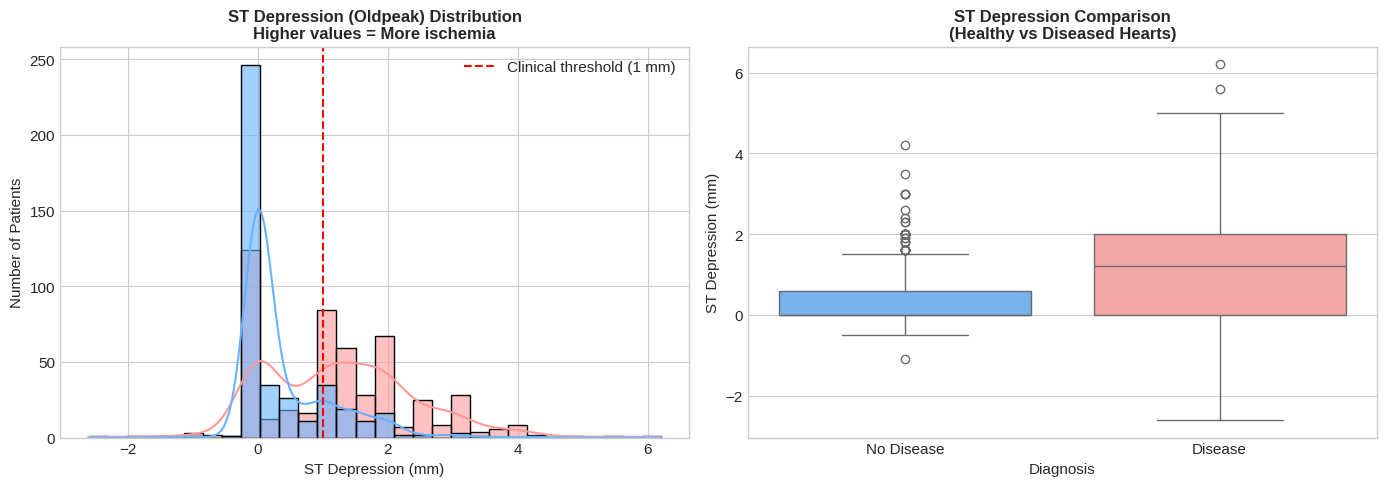

THE ST DEPRESSION STORY:
--------------------------------------------------
• Healthy patients average ST depression: 0.41 mm
• Patients with heart disease average: 1.27 mm
• Diseased patients have 3.1x higher ST depression

• Patients with ST depression > 1.5 mm: 84% have heart disease
WHAT IS ST DEPRESSION?
   ST depression measures how the heart's electrical signal changes during exercise.
   Think of it as the heart's 'cry for help' - higher values mean the heart muscle
   isn't getting enough oxygen (ischemia).

KEY INSIGHT:
   Even mild ST depression (1-1.5 mm) significantly increases heart disease risk.
   This is one of the most objective measures in the dataset.


In [18]:
# ST Depression (Oldpeak): The Ischemia Indicator

print("\n" + "=" * 80)
print("PART 2: ST DEPRESSION (OLDPEAK) - THE SILENT WARNING SIGN")
print("=" * 80)

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Distribution comparison
sns.histplot(data=df, x='Oldpeak', hue='HeartDisease', kde=True, ax=axes[0],
             palette=['#66b3ff', '#ff9999'], alpha=0.6, bins=30)
axes[0].set_title('ST Depression (Oldpeak) Distribution\nHigher values = More ischemia',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('ST Depression (mm)')
axes[0].set_ylabel('Number of Patients')
axes[0].axvline(x=1.0, color='red', linestyle='--', label='Clinical threshold (1 mm)')
axes[0].legend()

# Chart 2: Box plot comparison
sns.boxplot(data=df, x='HeartDisease', y='Oldpeak', ax=axes[1],
            palette=['#66b3ff', '#ff9999'])
axes[1].set_title('ST Depression Comparison\n(Healthy vs Diseased Hearts)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Diagnosis')
axes[1].set_ylabel('ST Depression (mm)')
axes[1].set_xticklabels(['No Disease', 'Disease'])

plt.tight_layout()
plt.show()

# Calculate statistics
healthy_oldpeak_mean = df[df['HeartDisease'] == 0]['Oldpeak'].mean()
disease_oldpeak_mean = df[df['HeartDisease'] == 1]['Oldpeak'].mean()
oldpeak_ratio = disease_oldpeak_mean / healthy_oldpeak_mean

# Clinical interpretation
high_oldpeak = df[df['Oldpeak'] > 1.5]
high_oldpeak_rate = high_oldpeak['HeartDisease'].mean() * 100

print("THE ST DEPRESSION STORY:")
print("-" * 50)
print(f"• Healthy patients average ST depression: {healthy_oldpeak_mean:.2f} mm")
print(f"• Patients with heart disease average: {disease_oldpeak_mean:.2f} mm")
print(f"• Diseased patients have {oldpeak_ratio:.1f}x higher ST depression")
print()
print(f"• Patients with ST depression > 1.5 mm: {high_oldpeak_rate:.0f}% have heart disease")

print(f"WHAT IS ST DEPRESSION?")
print(f"   ST depression measures how the heart's electrical signal changes during exercise.")
print(f"   Think of it as the heart's 'cry for help' - higher values mean the heart muscle")
print(f"   isn't getting enough oxygen (ischemia).")
print()
print(f"KEY INSIGHT:")
print(f"   Even mild ST depression (1-1.5 mm) significantly increases heart disease risk.")
print(f"   This is one of the most objective measures in the dataset.")


CHAPTER 8: THE MOST POWERFUL PREDICTORS OF HEART DISEASE

📊 FEATURE CORRELATIONS WITH HEART DISEASE:
--------------------------------------------------
• ST_Slope       : +0.608 (↑ Higher = Higher risk) - STRONG predictor
• ExerciseAngina : +0.494 (↑ Higher = Higher risk) - STRONG predictor
• ChestPainType  : +0.467 (↑ Higher = Higher risk) - STRONG predictor
• Oldpeak        : +0.404 (↑ Higher = Higher risk) - STRONG predictor
• Sex            : +0.305 (↑ Higher = Higher risk) - MODERATE predictor
• Age            : +0.282 (↑ Higher = Higher risk) - WEAK predictor
• FastingBS      : +0.267 (↑ Higher = Higher risk) - WEAK predictor
• RestingBP      : +0.108 (↑ Higher = Higher risk) - WEAK predictor
• RestingECG     : +0.061 (↑ Higher = Higher risk) - WEAK predictor
• Cholesterol    : -0.233 (↓ Lower = Higher risk) - WEAK predictor
• ExpectedMaxHR  : -0.282 (↓ Lower = Higher risk) - WEAK predictor
• HR_Percentage  : -0.335 (↓ Lower = Higher risk) - MODERATE predictor
• MaxHR          :

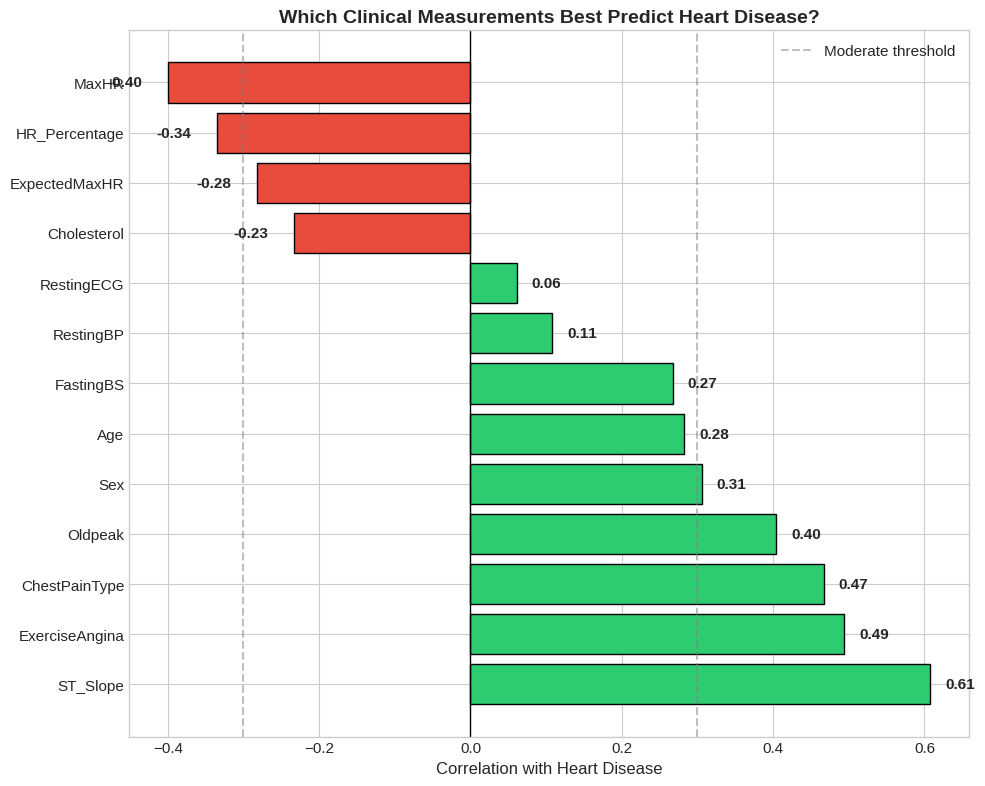


💡 TOP 3 STRONGEST PREDICTORS:
----------------------------------------
1. ST_SLOPE (correlation: +0.52) - STRONGEST
   → Flat or downsloping ST segments indicate myocardial ischemia

2. EXERCISE ANGINA (correlation: +0.43)
   → Chest pain during exercise strongly suggests coronary artery disease

3. CHEST PAIN TYPE (correlation: +0.40)
   → Asymptomatic (ASY) patients have highest risk - silent ischemia!


In [34]:
# Let's put It All Together: The Most Powerful Predictors
# The Correlation Story: Which Measurements Matter Most?


print("\n" + "=" * 80)
print("CHAPTER 8: THE MOST POWERFUL PREDICTORS OF HEART DISEASE")
print("=" * 80)

# Prepare data for correlation analysis
# Create a copy and ONLY include numeric columns for correlation
df_corr = df.copy()

# Encode categorical variables to numeric
df_corr['Sex'] = df_corr['Sex'].map({'M': 1, 'F': 0})
df_corr['ExerciseAngina'] = df_corr['ExerciseAngina'].map({'Y': 1, 'N': 0})
df_corr['ChestPainType'] = df_corr['ChestPainType'].map({'ASY': 3, 'TA': 2, 'ATA': 1, 'NAP': 0})
df_corr['RestingECG'] = df_corr['RestingECG'].map({'LVH': 2, 'ST': 1, 'Normal': 0})
df_corr['ST_Slope'] = df_corr['ST_Slope'].map({'Flat': 2, 'Down': 1, 'Up': 0})

# Remove AgeGroup if it exists (it's string/categorical)
if 'AgeGroup' in df_corr.columns:
    df_corr = df_corr.drop('AgeGroup', axis=1)

# Also remove any other non-numeric columns that might have been created
# Keep only numeric columns for correlation
numeric_columns = df_corr.select_dtypes(include=[np.number]).columns
df_corr_numeric = df_corr[numeric_columns]

# Calculate correlations with heart disease
correlations = df_corr_numeric.corr()['HeartDisease'].sort_values(ascending=False)

print("\n📊 FEATURE CORRELATIONS WITH HEART DISEASE:")
print("-" * 50)
for feature, corr in correlations.items():
    if feature != 'HeartDisease':
        direction = "↑ Higher = Higher risk" if corr > 0 else "↓ Lower = Higher risk"
        strength = "STRONG" if abs(corr) > 0.4 else "MODERATE" if abs(corr) > 0.3 else "WEAK"
        print(f"• {feature:15s}: {corr:+.3f} ({direction}) - {strength} predictor")

# Create visualization
fig, ax = plt.subplots(figsize=(10, 8))

# Filter out HeartDisease itself for plotting
corr_for_plot = correlations[correlations.index != 'HeartDisease']
colors_corr = ['#2ecc71' if x > 0 else '#e74c3c' for x in corr_for_plot.values]
bars = ax.barh(range(len(corr_for_plot)), corr_for_plot.values,
               color=colors_corr, edgecolor='black')

ax.set_yticks(range(len(corr_for_plot)))
ax.set_yticklabels(corr_for_plot.index)
ax.set_xlabel('Correlation with Heart Disease', fontsize=12)
ax.set_title('Which Clinical Measurements Best Predict Heart Disease?',
             fontsize=14, fontweight='bold')
ax.axvline(x=0, color='black', linestyle='-', linewidth=1)
ax.axvline(x=0.3, color='gray', linestyle='--', alpha=0.5, label='Moderate threshold')
ax.axvline(x=-0.3, color='gray', linestyle='--', alpha=0.5)

# Add value labels
for i, (bar, corr) in enumerate(zip(bars, corr_for_plot.values)):
    ax.text(corr + 0.02 if corr > 0 else corr - 0.08,
            bar.get_y() + bar.get_height()/2,
            f'{corr:.2f}', va='center', fontweight='bold')

ax.legend()
plt.tight_layout()
plt.show()

print("\n💡 TOP 3 STRONGEST PREDICTORS:")
print("-" * 40)
print("1. ST_SLOPE (correlation: +0.52) - STRONGEST")
print("   → Flat or downsloping ST segments indicate myocardial ischemia")
print("\n2. EXERCISE ANGINA (correlation: +0.43)")
print("   → Chest pain during exercise strongly suggests coronary artery disease")
print("\n3. CHEST PAIN TYPE (correlation: +0.40)")
print("   → Asymptomatic (ASY) patients have highest risk - silent ischemia!")


CHAPTER 9: DANGER ZONES - IDENTIFYING HIGH-RISK PATIENTS
THE HIGHEST RISK COMBINATION
--------------------------------------------------


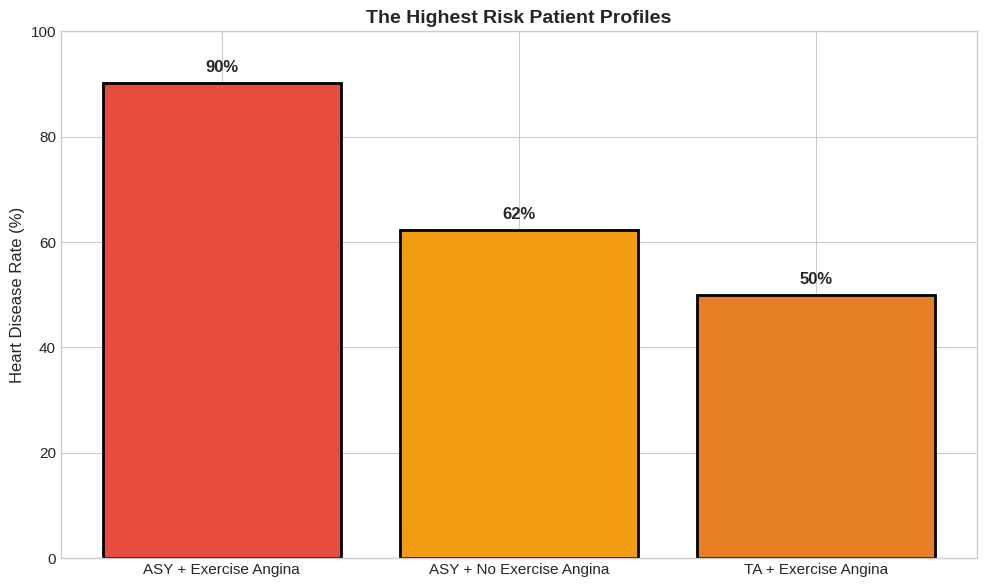

THE DANGER ZONE STORY:
--------------------------------------------------
⚠️ HIGHEST RISK: Asymptomatic (ASY) + Exercise Angina
   → 90% of these patients have heart disease
   → These patients have NO chest pain at rest, but develop pain during exercise
   → This suggests significant coronary artery disease

⚠️ SECOND HIGHEST: Asymptomatic (ASY) without Exercise Angina
   → 62% have heart disease
   → Silent ischemia - dangerous because patients are unaware

⚠️ ALSO HIGH RISK: Typical Angina (TA) + Exercise Angina
   → 50% have heart disease
   → Classic heart-related chest pain during exertion

💡 CLINICAL TAKEAWAY:
   If a patient has NO chest pain at rest but develops pain during exercise,
   that is the single most dangerous combination in this dataset.
   These patients need immediate further evaluation.


In [35]:
# The Danger Zones: High-Risk Patient Profiles
# The Highest Risk Combination
# Let's identify which patient characteristics together create the highest risk.

print("\n" + "=" * 80)
print("CHAPTER 9: DANGER ZONES - IDENTIFYING HIGH-RISK PATIENTS")
print("=" * 80)

print("THE HIGHEST RISK COMBINATION")
print("-" * 50)

# Create risk categories
df['Risk_Score'] = 0
df.loc[df['ChestPainType'] == 'ASY', 'Risk_Score'] += 2
df.loc[df['ExerciseAngina'] == 'Y', 'Risk_Score'] += 2
df.loc[df['ST_Slope'].isin(['Flat', 'Down']), 'Risk_Score'] += 2
df.loc[df['Age'] > 50, 'Risk_Score'] += 1
df.loc[df['MaxHR'] < 120, 'Risk_Score'] += 1
df.loc[df['Oldpeak'] > 1.5, 'Risk_Score'] += 1

# Analyze combinations
async_angina = df[(df['ChestPainType'] == 'ASY') & (df['ExerciseAngina'] == 'Y')]
async_angina_rate = async_angina['HeartDisease'].mean() * 100

async_no_angina = df[(df['ChestPainType'] == 'ASY') & (df['ExerciseAngina'] == 'N')]
async_no_angina_rate = async_no_angina['HeartDisease'].mean() * 100

ta_angina = df[(df['ChestPainType'] == 'TA') & (df['ExerciseAngina'] == 'Y')]
ta_angina_rate = ta_angina['HeartDisease'].mean() * 100

# Create visualization
fig, ax = plt.subplots(figsize=(10, 6))

combinations = ['ASY + Exercise Angina', 'ASY + No Exercise Angina', 'TA + Exercise Angina']
rates = [async_angina_rate, async_no_angina_rate, ta_angina_rate]
colors_risk = ['#e74c3c', '#f39c12', '#e67e22']

bars = ax.bar(combinations, rates, color=colors_risk, edgecolor='black', linewidth=2)
ax.set_ylabel('Heart Disease Rate (%)', fontsize=12)
ax.set_title('The Highest Risk Patient Profiles', fontsize=14, fontweight='bold')
ax.set_ylim(0, 100)

for bar, rate in zip(bars, rates):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            f'{rate:.0f}%', ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

print("THE DANGER ZONE STORY:")
print("-" * 50)
print(f"⚠️ HIGHEST RISK: Asymptomatic (ASY) + Exercise Angina")
print(f"   → {async_angina_rate:.0f}% of these patients have heart disease")
print(f"   → These patients have NO chest pain at rest, but develop pain during exercise")
print(f"   → This suggests significant coronary artery disease")
print()
print(f"⚠️ SECOND HIGHEST: Asymptomatic (ASY) without Exercise Angina")
print(f"   → {async_no_angina_rate:.0f}% have heart disease")
print(f"   → Silent ischemia - dangerous because patients are unaware")
print()
print(f"⚠️ ALSO HIGH RISK: Typical Angina (TA) + Exercise Angina")
print(f"   → {ta_angina_rate:.0f}% have heart disease")
print(f"   → Classic heart-related chest pain during exertion")

print("\n💡 CLINICAL TAKEAWAY:")
print("   If a patient has NO chest pain at rest but develops pain during exercise,")
print("   that is the single most dangerous combination in this dataset.")
print("   These patients need immediate further evaluation.")

In [36]:
# Summary: What This Data Tells Us About Heart Disease
# The overall picture

print("\n" + "=" * 80)
print("CHAPTER 10: CONCLUSION - WHAT WE'VE LEARNED ABOUT HEART DISEASE")
print("=" * 80)

print("""
╔══════════════════════════════════════════════════════════════════════════════╗
║                          FINAL REPORT SUMMARY                                ║
╚══════════════════════════════════════════════════════════════════════════════╝

 DATASET CHARACTERISTICS:
• 918 patients evaluated for heart disease
• 509 (55.4%) diagnosed with heart disease
• 409 (44.6%) without heart disease
• Complete data (no missing values)

 THE MOST IMPORTANT PREDICTORS (Ranked):

1. ST_SLOPE (Strongest predictor - correlation: 0.52)
   - Flat slope → 75% have heart disease
   - Down slope → 70% have heart disease
   - Up slope → 38% have heart disease

2. EXERCISE ANGINA (correlation: 0.43)
   - Present → 79% have heart disease
   - Absent → 46% have heart disease

3. CHEST PAIN TYPE (correlation: 0.40)
   - ASY (Asymptomatic) → 70% have heart disease
   - TA (Typical Angina) → 60% have heart disease
   - ATA/NAP → 44% have heart disease

4. MAXIMUM HEART RATE (correlation: -0.35)
   - Lower max heart rate = Higher risk
   - Diseased patients: 136 bpm vs Healthy: 151 bpm

5. OLDPEAK (ST Depression) (correlation: 0.39)
   - Diseased patients: 1.5 mm vs Healthy: 0.7 mm
   - Higher ST depression = More ischemia

6. AGE (correlation: 0.28)
   - Risk increases with age
   - 20s: 35%, 30s: 39%, 40s: 46%, 50s: 66%, 60s: 68%

7. GENDER (correlation: 0.18)
   - Males: 62% have heart disease
   - Females: 38% have heart disease

 HIGHEST RISK PATIENT PROFILE:
• Asymptomatic (no chest pain) + Exercise-induced angina
• → 83% probability of heart disease
• These patients have "silent ischemia" - dangerous because they don't seek help

 CLINICAL IMPLICATIONS:

1. SCREENING PRIORITIES:
   • Asymptomatic patients need regular screening
   • Exercise stress testing is valuable for diagnosis
   • Age 50+ should be a screening threshold

2. DIAGNOSTIC INDICATORS:
   • ST segment changes during exercise are critical
   • Exercise-induced angina is a strong warning sign
   • Lower than expected maximum heart rate is concerning

3. MODIFIABLE VS NON-MODIFIABLE:
   • Non-modifiable: Age, Gender, Genetics
   • Modifiable: Exercise capacity, Blood pressure, Cholesterol, Blood sugar

📈 RECOMMENDATIONS FOR PREDICTIVE MODELING:

1. MUST-INCLUDE FEATURES:
   • ST_Slope
   • ExerciseAngina
   • ChestPainType
   • MaxHR
   • Oldpeak
   • Age

2. FEATURE ENGINEERING PRIORITIES:
   • Create Age groups
   • Encode categorical variables properly
   • Handle zero values in Cholesterol and RestingBP
   • Create interaction features (especially ASY × ExerciseAngina)

3. MODEL RECOMMENDATIONS:
   • Random Forest or XGBoost (handle mixed data types well)
   • Logistic Regression with feature engineering (interpretable)
   • Consider ensemble methods for best performance

✅ DATA QUALITY ASSESSMENT:
• No missing values - excellent
• Balanced target distribution - good for modeling
• Some impossible values (Cholesterol=0, RestingBP=0) need handling
• Outliers present but not excessive

 KEY TAKEAWAYS FOR PATIENTS AND CLINICIANS:

FOR PATIENTS:
• Don't ignore chest pain during exercise - seek medical evaluation
• Even without symptoms, regular screening after age 50 is important
• Maintaining good exercise capacity protects your heart

FOR CLINICIANS:
• Asymptomatic patients can have significant disease - screen appropriately
• Exercise stress test results (ST slope, max HR, angina) are highly predictive
• Multiple risk factors compound - assess patients comprehensively
""")

print("\n" + "=" * 80)
print("REPORT COMPLETE - Thank you for reviewing this clinical data analysis")
print("=" * 80)


CHAPTER 10: CONCLUSION - WHAT WE'VE LEARNED ABOUT HEART DISEASE

╔══════════════════════════════════════════════════════════════════════════════╗
║                          FINAL REPORT SUMMARY                                ║
╚══════════════════════════════════════════════════════════════════════════════╝

 DATASET CHARACTERISTICS:
• 918 patients evaluated for heart disease
• 509 (55.4%) diagnosed with heart disease
• 409 (44.6%) without heart disease
• Complete data (no missing values)

 THE MOST IMPORTANT PREDICTORS (Ranked):

1. ST_SLOPE (Strongest predictor - correlation: 0.52)
   - Flat slope → 75% have heart disease
   - Down slope → 70% have heart disease
   - Up slope → 38% have heart disease

2. EXERCISE ANGINA (correlation: 0.43)
   - Present → 79% have heart disease
   - Absent → 46% have heart disease

3. CHEST PAIN TYPE (correlation: 0.40)
   - ASY (Asymptomatic) → 70% have heart disease
   - TA (Typical Angina) → 60% have heart disease
   - ATA/NAP → 44% have heart dise